# Melanoma Detection

In [180]:
# Imports
import os
import time
import shutil
import random
import kagglehub
import polars as pl
import torch
from torch import nn
import torchvision
import torchmetrics
from torcheval.metrics import (
    MulticlassAccuracy, 
    MulticlassPrecision, 
    MulticlassRecall, 
    MulticlassF1Score, 
    MulticlassConfusionMatrix
)
from tqdm import tqdm
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Preparing Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("andrewmvd/isic-2019")

print("Path to dataset files:", path)

Path to dataset files: /home/cam/.cache/kagglehub/datasets/andrewmvd/isic-2019/versions/1


In [4]:
!ls {path}

ISIC_2019_Training_GroundTruth.csv  ISIC_2019_Training_Metadata.csv
ISIC_2019_Training_Input


In [5]:
df_meta = pl.read_csv(os.path.join(path, "ISIC_2019_Training_Metadata.csv"))
df_labels = pl.read_csv(os.path.join(path, "ISIC_2019_Training_GroundTruth.csv"))
df_meta.head(), df_labels.head()

(shape: (5, 5)
 ┌──────────────┬────────────┬─────────────────────┬───────────┬────────┐
 │ image        ┆ age_approx ┆ anatom_site_general ┆ lesion_id ┆ sex    │
 │ ---          ┆ ---        ┆ ---                 ┆ ---       ┆ ---    │
 │ str          ┆ i64        ┆ str                 ┆ str       ┆ str    │
 ╞══════════════╪════════════╪═════════════════════╪═══════════╪════════╡
 │ ISIC_0000000 ┆ 55         ┆ anterior torso      ┆ null      ┆ female │
 │ ISIC_0000001 ┆ 30         ┆ anterior torso      ┆ null      ┆ female │
 │ ISIC_0000002 ┆ 60         ┆ upper extremity     ┆ null      ┆ female │
 │ ISIC_0000003 ┆ 30         ┆ upper extremity     ┆ null      ┆ male   │
 │ ISIC_0000004 ┆ 80         ┆ posterior torso     ┆ null      ┆ male   │
 └──────────────┴────────────┴─────────────────────┴───────────┴────────┘,
 shape: (5, 10)
 ┌──────────────┬─────┬─────┬─────┬───┬─────┬──────┬─────┬─────┐
 │ image        ┆ MEL ┆ NV  ┆ BCC ┆ … ┆ DF  ┆ VASC ┆ SCC ┆ UNK │
 │ ---          ┆ --- ┆ 

In [6]:
df_labels[8]

image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ISIC_0000009""",0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# CANCER
df_labels.filter(pl.col("MEL") == 1)

image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ISIC_0000002""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ISIC_0000004""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ISIC_0000013""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ISIC_0000022_downsampled""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ISIC_0000026_downsampled""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…
"""ISIC_0073231""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ISIC_0073237""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ISIC_0073238""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df_labels.shape[0]

25331

In [9]:
# Uh oh, no samples
df_labels.filter(pl.col("UNK") == 1)

image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
str,f64,f64,f64,f64,f64,f64,f64,f64,f64


In [10]:
# Drop "Unknown" column for training, no samples in dataset
df_labels = df_labels.drop(pl.col("UNK"))
df_labels.shape[0]
# Notice, no change in # of samples

25331

In [11]:
# Define train test split
train_size = 0.9
valid_size = 0.1

train_len = int(df_labels.shape[0] * 0.9)
valid_len = df_labels.shape[0] - train_len
is_train = ([True] * train_len) + ([False] * valid_len)
random.shuffle(is_train)
is_train[:10], len(is_train)

([True, True, True, False, True, True, True, True, True, False], 25331)

In [12]:
# Move data into folders for Pytorch Data Loader
image_path = os.path.join(path, "ISIC_2019_Training_Input", "ISIC_2019_Training_Input")
train_path = os.path.join(image_path, "train")
valid_path = os.path.join(image_path, "valid")
os.makedirs(train_path, exist_ok=True)
os.makedirs(valid_path, exist_ok=True)

for idx, image_name in enumerate(df_labels["image"]):
    folder = train_path if is_train[idx] else valid_path
    image = os.path.join(image_path, f"{image_name}.jpg")
    if os.path.exists(image):
        shutil.copy(image, os.path.join(folder, f"{image_name}.jpg"))

## Loading the Data

In [13]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, df_labels, img_dir, transform=None, target_transform=None):
        self.img_names = df_labels["image"]
        self.img_labels = df_labels.drop(pl.col("image")).to_torch().to(device)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx] + ".jpg")
        image = torchvision.io.read_image(img_path)
        label = self.img_labels[idx]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [86]:
df = df_labels.with_columns(train = pl.Series(is_train))
df_train = df.filter(pl.col("train") == True).drop("train")
df_valid = df.filter(pl.col("train") == False).drop("train")
transforms = torchvision.models.VGG16_Weights.IMAGENET1K_V1.transforms()

train_ds = ImageDataset(df_train, train_path, transform=transforms)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)

valid_ds = ImageDataset(df_valid, valid_path, transform=transforms)
valid_loader = torch.utils.data.DataLoader(valid_ds, batch_size=32, shuffle=True)

transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

## Fine Tuning a VGG16 Classifier

In [31]:
def train_model(
    model: nn.Module, 
    opt: torch.optim.Optimizer,
    dataloader: torch.utils.data.DataLoader,
    criterion: nn.Module = nn.CrossEntropyLoss(),
    epochs: int = 100,
):
    model.train()  # set model to training mode
    
    for epoch in range(epochs):
        avg_loss = 0
        for X_batch, y_batch in tqdm(dataloader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            opt.zero_grad()
            z = model(X_batch)
            # print(f'{z}, {y_batch}')
            loss = criterion(z, y_batch)
            loss.backward()
            opt.step()
            avg_loss += loss.item()
            # print(loss)
        print(f'loss: {avg_loss / dataloader.batch_size}')

In [22]:
def calc_accuracy(model: nn.Module, dataloader) -> float:
    metric = MulticlassAccuracy(num_classes=8)
    model.eval()  # set model to evaluation mode, disable certain features
    sum_ = 0
    count = 0
    with torch.no_grad():  # disable gradient calculations
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            z = model(X_batch)
            sum_ += (torch.argmax(z, dim=-1) == torch.argmax(y_batch, dim=-1)).sum().item()
            count += y_batch.shape[0]
    return sum_ / count

In [40]:
# Define Vgg model with predefined weights and custom MLP Classifier
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
vgg.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, 8),
)
vgg = vgg.to(device)

In [42]:
lr = 0.01
momentum = 0.9
epochs = 25
opt = torch.optim.SGD(vgg.parameters(), lr=lr, momentum=momentum)
train_model(vgg, opt, train_loader, epochs=epochs)

100%|█████████████████████████████████████████| 713/713 [03:19<00:00,  3.57it/s]


loss: 24.986041772437524


100%|█████████████████████████████████████████| 713/713 [03:18<00:00,  3.59it/s]


loss: 21.034484642435626


100%|█████████████████████████████████████████| 713/713 [03:13<00:00,  3.69it/s]


...

loss: 2.693476060803339


100%|█████████████████████████████████████████| 713/713 [03:01<00:00,  3.93it/s]


loss: 2.50562430398082


100%|█████████████████████████████████████████| 713/713 [03:01<00:00,  3.93it/s]

loss: 2.0739555922196318


In [43]:

calc_accuracy(vgg, train_loader), calc_accuracy(vgg, valid_loader)

(0.9764442689827609, 0.749802683504341)

In [44]:
torch.save(vgg.state_dict(), 'vgg.pt')

## Fine Tuning a Resnet50 Classifier

In [29]:
# Define Resnet model with predefined weights and correctly sized output layer
resnet = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2).to(device)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 8)
resnet = resnet.to(device)

In [36]:
lr = 0.01
momentum = 0.9
epochs = 25
opt = torch.optim.SGD(resnet.parameters(), lr=lr, momentum=momentum)
train_model(resnet, opt, train_loader, epochs=epochs)

100%|█████████████████████████████████████████| 713/713 [02:27<00:00,  4.84it/s]


loss: 11.633508244519886


100%|█████████████████████████████████████████| 713/713 [02:25<00:00,  4.90it/s]


loss: 8.310525557594726


100%|█████████████████████████████████████████| 713/713 [02:26<00:00,  4.87it/s]


...

loss: 0.2348345105385879


100%|█████████████████████████████████████████| 713/713 [02:16<00:00,  5.24it/s]


loss: 0.12859963030104615


100%|█████████████████████████████████████████| 713/713 [02:20<00:00,  5.07it/s]

loss: 0.04723275332623307


In [37]:
calc_accuracy(resnet, train_loader), calc_accuracy(resnet, valid_loader)

(0.9999122691582226, 0.8385951065509076)

In [89]:
vgg = torchvision.models.vgg16()
vgg.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(),
    nn.Linear(4096, 8),
)
vgg = vgg.to(device)
vgg.load_state_dict(torch.load("vgg.pt"))

resnet = torchvision.models.resnet50()
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 8)
resnet = resnet.to(device)
resnet.load_state_dict(torch.load("resnet.pt"))

<All keys matched successfully>

## Evaluation

In [164]:
path = "/home/cam/Documents/ISIC_2019"
test_path = os.path.join(path, "ISIC_2019_Test_Input")
df_meta = pl.read_csv(os.path.join(path, "ISIC_2019_Test_Metadata.csv"))
df_labels = pl.read_csv(os.path.join(path, "ISIC_2019_Test_GroundTruth.csv"))
df_labels = df_labels.filter(pl.col("UNK") == 0).drop(pl.col("UNK"))
test_ds = ImageDataset(df_labels, test_path, transform=transforms)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=True)

In [176]:
def calc_metrics(model: nn.Module, dataloader):
    model.eval()  # set model to evaluation mode, disable certain features
    
    acc = MulticlassAccuracy(num_classes=8)
    pre = MulticlassPrecision(num_classes=8, average='macro')
    rec = MulticlassRecall(num_classes=8, average='macro')
    f1 = MulticlassF1Score(num_classes=8, average='macro')
    conf = MulticlassConfusionMatrix(num_classes=8)
    
    with torch.no_grad():  # disable gradient calculations
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            z = model(X_batch)
            pred, label = torch.argmax(z, dim=-1), torch.argmax(y_batch, dim=-1)
            
            acc.update(pred, label)
            pre.update(pred, label)
            rec.update(pred, label)
            f1.update(pred, label)
            conf.update(pred, label)
            
    print(f"Accuracy: {acc.compute()}")
    print(f"Precision: {pre.compute()}")
    print(f"Recall: {rec.compute()}")
    print(f"F1 Score: {f1.compute()}")
   
    df_cm = pd.DataFrame(conf.compute(), index = df_labels.columns[1:9],
                  columns = df_labels.columns[1:9])
    plt.figure(figsize = (10,7))
    sn.heatmap(df_cm, annot=True, cmap='magma_r')
    return df_cm

Accuracy: 0.6880956292152405
Precision: 0.5907866358757019
Recall: 0.48741957545280457
F1 Score: 0.5188902616500854


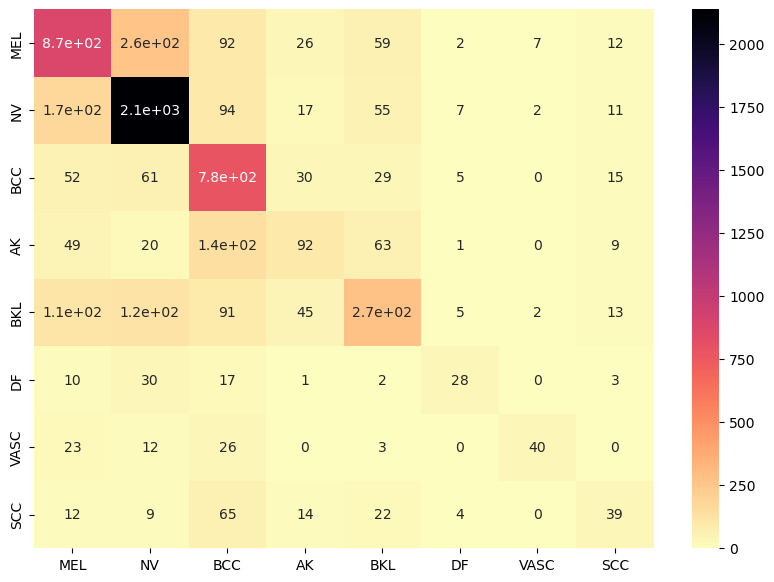

In [177]:
df_cm = calc_metrics(resnet, test_loader)

Accuracy: 0.5978032350540161
Precision: 0.4404911994934082
Recall: 0.3846283257007599
F1 Score: 0.3920482397079468


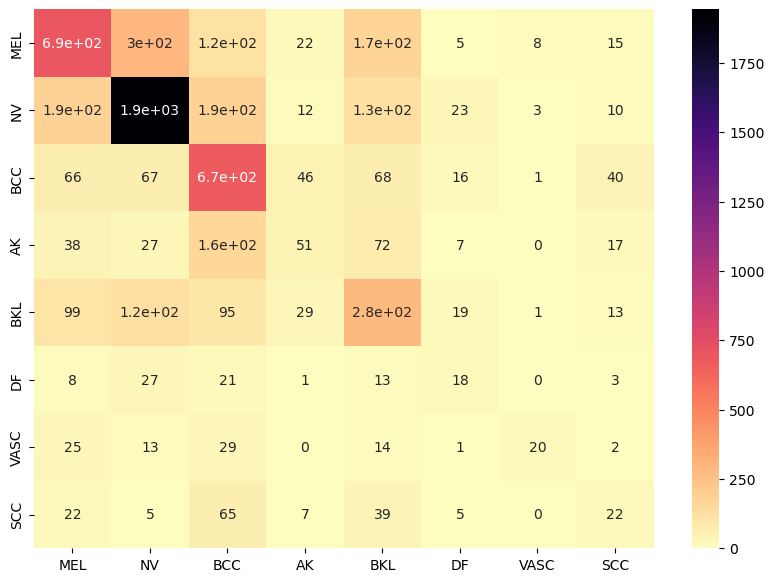

In [178]:
df_cm = calc_metrics(vgg, test_loader)

## Visualization

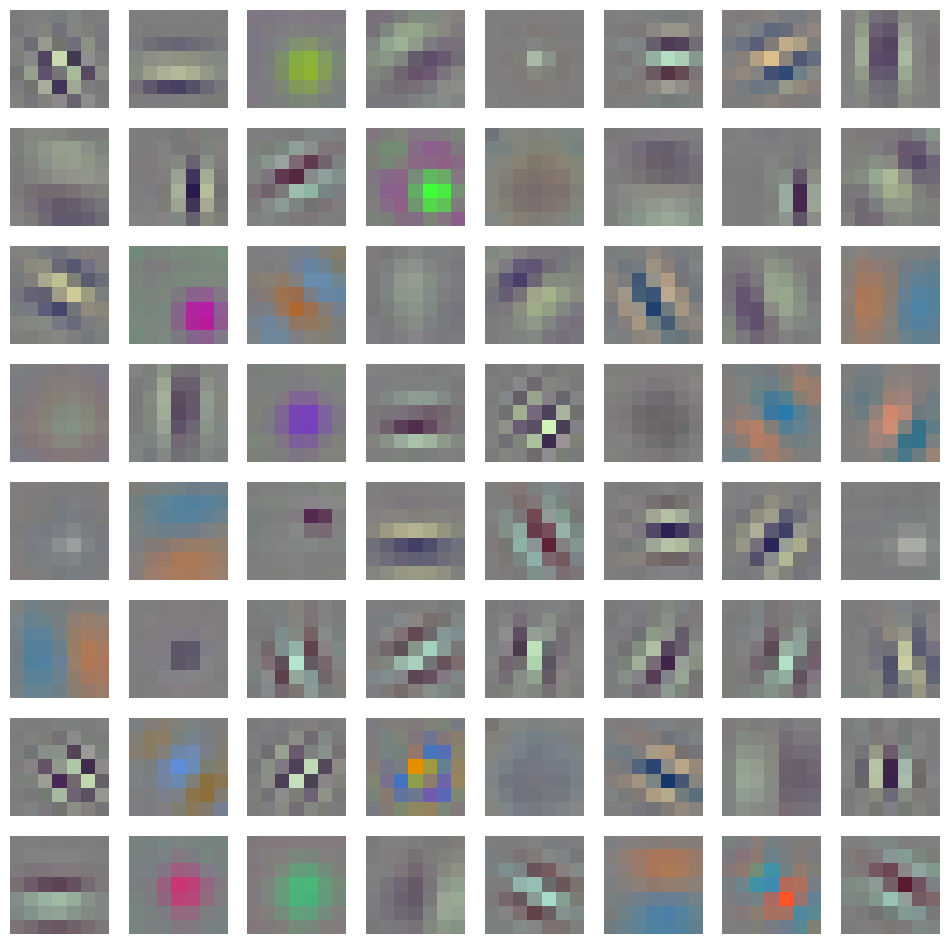

In [179]:
# Extract the first conv layer
first_conv_layer = resnet.conv1
weights = first_conv_layer.weight.data  # Shape: [64, 3, 7, 7]

# Normalize weights to [0, 1] for visualization
weights_min = weights.min()
weights_max = weights.max()
normalized_weights = (weights - weights_min) / (weights_max - weights_min)

# Plot filters
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
axes = axes.flatten()

for i in range(64):  # 64 filters in the first conv layer
    ax = axes[i]
    # Select the ith filter (3 channels)
    filter_img = normalized_weights[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(filter_img)
    ax.axis('off')

plt.show()


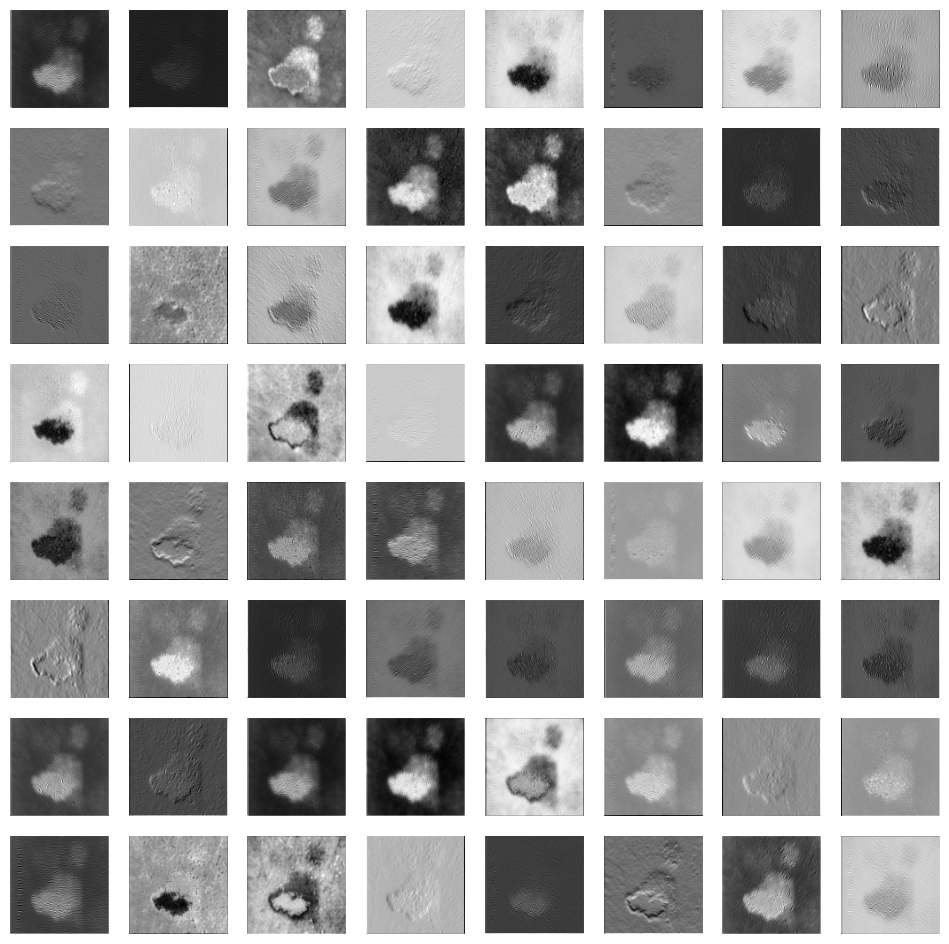

In [194]:
# Load and preprocess an image
img = Image.open(os.path.join(test_path, df_labels.filter(pl.col("MEL") == 1)["image"][0] + ".jpg"))
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
])
img_tensor = transform(img).unsqueeze(0).to(device)  # Add batch dimension

# Forward pass through the first conv layer
with torch.no_grad():
    activation = first_conv_layer(img_tensor)

# Plot the activations
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
axes = axes.flatten()

for i in range(64):
    ax = axes[i]
    ax.imshow(activation[0, i].cpu().numpy(), cmap='gray')
    ax.axis('off')

plt.show()
